# Station placement: optimize and evaluate
Answers the three questions with the functions in `stations.py`, using the candidates, demand and
travel-time matrices from `04_candidates_costs`. Stations are chosen on 2019–2022 (train) and
tested on 2023. Everything is saved to `data/processed/results/` for the web app.

- **Coverage** is the share of fire weight within the threshold of its nearest open station.
- **Ceiling** is the coverage with all candidates open. "Relative" coverage is coverage ÷ ceiling.

## Config

In [1]:
from pathlib import Path
from itertools import combinations
import json
import sys
import time
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer
from IPython.display import display

folder = Path.cwd().resolve()
REPO_ROOT = next((p for p in (folder, *folder.parents) if (p / "CLAUDE.md").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Launch from inside the repository.")
sys.path.insert(0, str(REPO_ROOT / "notebooks"))
import stations as st
from bc_geo import load_bc_boundary

warnings.filterwarnings("ignore", category=DeprecationWarning)  # PuLP 4 notices raised inside spopt

model = st.load_model()
config = model["config"]
THRESHOLD_MIN = config["THRESHOLD_MIN"]

K_MAX = 60
K_EXTENDED = 200                 # Q2 is re-run this far if the target is not reached by K_MAX
CAP_MIN = 2 * THRESHOLD_MIN      # capped p-median: minutes beyond this count as this
TARGET = 0.95                    # Q2 target, as a share of the ceiling
TRUCK_PERCENTILE = 90
TRUCK_BUSY_DAYS_ONLY = True      # percentile over the days a station has at least one active fire
THRESHOLDS = [30, 60, 90]
EXACT_KS = [5, 10, 20, 40]
REPORT_KS = [10, 20, 40, 60]
LOYO_K = 20
NEXT_N = 20
HALL_BUDGET_FACTORS = [1, 1.5, 2]
FAIR_KS = [10, 20, 40]
SENSITIVITY_K = 20
PMEDIAN_CELL_KM = 20
EXACT_PMEDIAN_KS = [5, 10, 20]
EXACT_PMEDIAN_LIMIT_S = 120
RUN_EXACT_PMEDIAN = False        # it timed out at every K; the saved results are kept
Q1_PRIMARY = "capped"           # the Q1 variant the web app shows
BASELINE_KS = [10, 20, 40]
N_RANDOM_LAYOUTS = 1000
RANDOM_SEED = 0

RESULTS_DIR = REPO_ROOT / "data" / "processed" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

candidates = model["candidates"]
demand_train, demand_test = model["demand_train"], model["demand_test"]
cost_train, cost_test = model["cost_train"], model["cost_test"]
w_train, w_test = demand_train["weight"].to_numpy(), demand_test["weight"].to_numpy()
capped_train = np.minimum(cost_train, CAP_MIN)
bc = load_bc_boundary()
summary = {"THRESHOLD_MIN": THRESHOLD_MIN, "K_MAX": K_MAX, "CAP_MIN": CAP_MIN, "TARGET": TARGET,
           "TRUCK_PERCENTILE": TRUCK_PERCENTILE, "TRUCK_BUSY_DAYS_ONLY": TRUCK_BUSY_DAYS_ONLY,
           "q1_primary": Q1_PRIMARY, "n_candidates": len(candidates),
           "ceiling_train": st.ceiling(cost_train, w_train, THRESHOLD_MIN),
           "ceiling_test": st.ceiling(cost_test, w_test, THRESHOLD_MIN)}
print(f"{len(candidates)} candidates, {len(demand_train):,} train fires, {len(demand_test):,} test fires, "
      f"threshold {THRESHOLD_MIN} min, cap {CAP_MIN} min")
print(f"Ceiling: train {summary['ceiling_train']:.1%}, test {summary['ceiling_test']:.1%}")


def layout(sites):
    """The chosen sites as a table, in pick order (k = 1, 2, ...)."""
    table = candidates.loc[list(sites), ["cand_id", "name", "kind", "region", "lat", "lon"]].reset_index(drop=True)
    table.insert(0, "k", np.arange(1, len(table) + 1))
    return table


def save(table, name, index=False):
    table.to_csv(RESULTS_DIR / name, index=index)


def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)


def trucks_for(demand, score, sites):
    """Trucks per station from its covered fires only; stations with no covered fire get 1."""
    covered = score["minutes"] <= THRESHOLD_MIN
    trucks = st.trucks_per_station(demand[covered], score["assignment"][covered], percentile=TRUCK_PERCENTILE,
                                   busy_days_only=TRUCK_BUSY_DAYS_ONLY)
    return trucks.reindex(sorted(sites), fill_value=1).rename_axis("cand_id")


def truck_distribution(trucks):
    """How many stations have 1, 2, 3 and 4 or more trucks."""
    return {"1": int((trucks == 1).sum()), "2": int((trucks == 2).sum()), "3": int((trucks == 3).sum()),
            "4+": int((trucks >= 4).sum())}

851 candidates, 4,671 train fires, 2,361 test fires, threshold 60 min, cap 120 min
Ceiling: train 77.8%, test 51.1%


## Q1. Best K stations for every K
Greedy p-median on the train fires up to K = 60, in two variants:

- **uncapped**: minimize total weighted minutes as they are;
- **capped**: minutes beyond 120 count as 120, so a few very remote fires cannot pull stations away from
  where most fires are.

The pick order is nested: the best K stations are the first K picks. Curves use real (uncapped) minutes.

train_coverage  train_relative  test_coverage  test_relative  \
variant  k                                                                  
uncapped 10           0.176           0.227          0.092          0.180   
         20           0.303           0.389          0.185          0.361   
         40           0.522           0.671          0.296          0.578   
         60           0.634           0.814          0.362          0.707   
capped   10           0.230           0.295          0.110          0.215   
         20           0.377           0.484          0.193          0.378   
         40           0.558           0.717          0.321          0.627   
         60           0.659           0.847          0.392          0.768   

             train_mean_min  test_mean_min  
variant  k                                  
uncapped 10         121.745        178.527  
         20          88.234        136.275  
         40          65.002         92.853  
         60          56.916         86.479  
capped   10         125.000        181.985  
         20          92.927        152.665  
         40          69.663        123.631  
         60          62.578        119.116

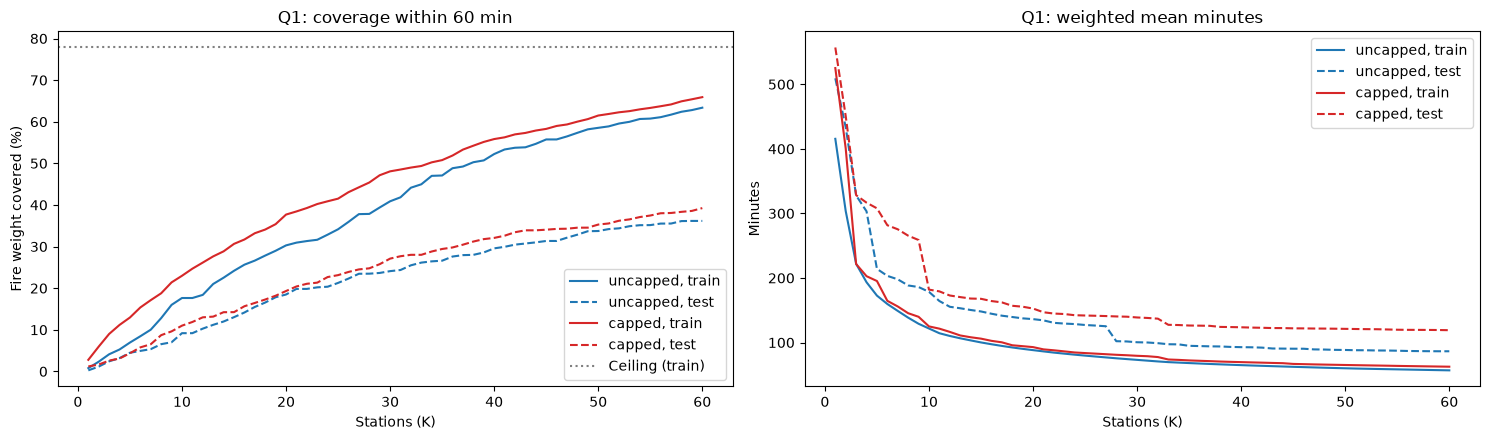

In [2]:
q1 = {}
for variant, matrix in [("uncapped", cost_train), ("capped", capped_train)]:
    picks = st.greedy_pmedian(matrix, w_train, K_MAX)["picks"]
    q1[variant] = {"picks": picks,
                   "train": st.coverage_curve(cost_train, w_train, picks, THRESHOLD_MIN),
                   "test": st.coverage_curve(cost_test, w_test, picks, THRESHOLD_MIN)}

rows = []
for variant in q1:
    for k in REPORT_KS:
        train, test = q1[variant]["train"].iloc[k - 1], q1[variant]["test"].iloc[k - 1]
        rows.append({"variant": variant, "k": k, "train_coverage": train["coverage"], "train_relative": train["coverage_relative"],
                     "test_coverage": test["coverage"], "test_relative": test["coverage_relative"],
                     "train_mean_min": train["mean_minutes"], "test_mean_min": test["mean_minutes"]})
q1_table = pd.DataFrame(rows)
display(q1_table.set_index(["variant", "k"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for variant, color in [("uncapped", "tab:blue"), ("capped", "tab:red")]:
    for split, style in [("train", "-"), ("test", "--")]:
        curve = q1[variant][split]
        axes[0].plot(curve["k"], 100 * curve["coverage"], style, color=color, label=f"{variant}, {split}")
        axes[1].plot(curve["k"], curve["mean_minutes"], style, color=color, label=f"{variant}, {split}")
axes[0].axhline(100 * summary["ceiling_train"], color="grey", linestyle=":", label="Ceiling (train)")
axes[0].set(title=f"Q1: coverage within {THRESHOLD_MIN} min", xlabel="Stations (K)", ylabel="Fire weight covered (%)")
axes[1].set(title="Q1: weighted mean minutes", xlabel="Stations (K)", ylabel="Minutes")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

for variant in q1:
    save(layout(q1[variant]["picks"]), f"q1_picks_{variant}.csv")
    save(q1[variant]["train"].merge(q1[variant]["test"], on=["k", "site"], suffixes=("_train", "_test")),
         f"q1_curve_{variant}.csv")
summary["q1"] = q1_table.round(4).to_dict("records")

## Q2. How many stations, and how many trucks
Greedy coverage on the train fires: each pick covers the most uncovered fire weight within the threshold.
**K\*** is the first K reaching 95% of the ceiling. If K = 60 is not enough, the run is extended to K = 200.

Run to K=60: {'k': None, 'status': 'not reachable', 'ceiling': 0.7784654786042045}


Run to K=200: {'k': 78, 'status': 'reached', 'ceiling': 0.7784654786042045}
K* = 78 stations reach 95% of the ceiling (74.0% of train weight; test 43.8%, 85.6% of the test ceiling)
Elbow: K = 62 on the curve to K=200; K = 24 on the curve to K=60


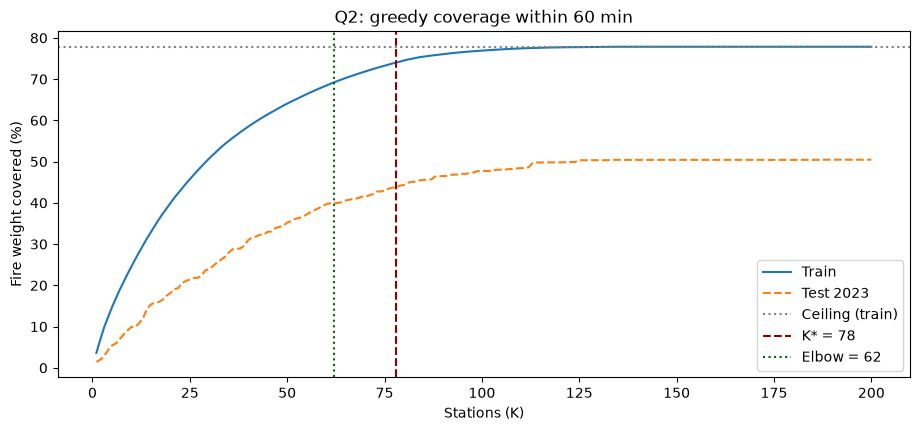

In [3]:
k_run = K_MAX
while True:
    q2_picks = st.greedy_coverage(cost_train, w_train, k_run, THRESHOLD_MIN)["picks"]
    q2_train = st.coverage_curve(cost_train, w_train, q2_picks, THRESHOLD_MIN)
    target = st.min_k_for_target(q2_train, TARGET, relative_to_ceiling=True)
    print(f"Run to K={k_run}: {target}")
    if target["status"] == "reached" or k_run >= K_EXTENDED:
        break
    k_run = K_EXTENDED
if target["status"] != "reached":
    raise RuntimeError(f"{TARGET:.0%} of the ceiling is not reached even at K={K_EXTENDED}.")
q2_test = st.coverage_curve(cost_test, w_test, q2_picks, THRESHOLD_MIN)
K_STAR = target["k"]
ELBOW_RUN = st.find_elbow(q2_train)
ELBOW_KMAX = st.find_elbow(q2_train.iloc[:K_MAX])
print(f"K* = {K_STAR} stations reach {TARGET:.0%} of the ceiling "
      f"({q2_train['coverage'].iloc[K_STAR - 1]:.1%} of train weight; test {q2_test['coverage'].iloc[K_STAR - 1]:.1%}, "
      f"{q2_test['coverage_relative'].iloc[K_STAR - 1]:.1%} of the test ceiling)")
print(f"Elbow: K = {ELBOW_RUN} on the curve to K={k_run}; K = {ELBOW_KMAX} on the curve to K={K_MAX}")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(q2_train["k"], 100 * q2_train["coverage"], color="tab:blue", label="Train")
ax.plot(q2_test["k"], 100 * q2_test["coverage"], "--", color="tab:orange", label="Test 2023")
ax.axhline(100 * summary["ceiling_train"], color="grey", linestyle=":", label="Ceiling (train)")
ax.axvline(K_STAR, color="darkred", linestyle="--", label=f"K* = {K_STAR}")
ax.axvline(ELBOW_RUN, color="darkgreen", linestyle=":", label=f"Elbow = {ELBOW_RUN}")
ax.set(title=f"Q2: greedy coverage within {THRESHOLD_MIN} min", xlabel="Stations (K)", ylabel="Fire weight covered (%)")
ax.legend()
plt.show()

### Trucks
Take the K\* layout. Each fire goes to its nearest station; a station only sends trucks to fires it can reach
within the threshold. Trucks per station = 90th percentile of the number of its fires active on the same day,
taken over the days on which the station has at least one active fire, rounded up, at least 1.

**Overload check on 2023**: with that layout and those trucks, count the station-days in 2023 on which a
station has more active fires than trucks.

In [4]:
def daily_active(demand, assignment, stations_list):
    """Active fires per day (rows) and station (columns) over the season spanned by `demand`."""
    first = demand["first_date"].to_numpy().astype("datetime64[D]")
    last = first + (demand["active_days_capped"].to_numpy() - 1).astype("timedelta64[D]")
    days = np.arange(first.min(), last.max() + np.timedelta64(1, "D"))
    counts = pd.DataFrame(0, index=pd.Index(days, name="day"), columns=list(stations_list))
    for station in stations_list:
        mine = assignment == station
        counts[station] = ((first[mine][None, :] <= days[:, None]) & (days[:, None] <= last[mine][None, :])).sum(axis=1)
    return counts


star_sites = q2_picks[:K_STAR]
star_train = st.evaluate(cost_train, w_train, star_sites, THRESHOLD_MIN, regions=demand_train["region"])
star_test = st.evaluate(cost_test, w_test, star_sites, THRESHOLD_MIN, regions=demand_test["region"])
star_trucks = trucks_for(demand_train, star_train, star_sites)
print(f"Trucks at the K* = {K_STAR} layout: {star_trucks.sum()} in total, max {star_trucks.max()} at one station; "
      f"stations by truck count: {truck_distribution(star_trucks)}")

covered_test = star_test["minutes"] <= THRESHOLD_MIN
# The season is taken from all 2023 fires; only covered fires create load.
season = daily_active(demand_test, np.full(len(demand_test), -1), []).index
load_2023 = daily_active(demand_test[covered_test], star_test["assignment"][covered_test], sorted(star_sites)).reindex(season, fill_value=0)
overloaded = load_2023.gt(star_trucks, axis=1)
OVERLOAD_SHARE = float(overloaded.to_numpy().mean())
print(f"2023 overload: {int(overloaded.to_numpy().sum()):,} of {overloaded.size:,} station-days ({OVERLOAD_SHARE:.1%}); "
      f"{int(overloaded.any().sum())} of {K_STAR} stations overloaded at least once; "
      f"worst day has {int(overloaded.sum(axis=1).max())} stations overloaded at once")

q2_stations = layout(star_sites)
q2_stations["trucks"] = star_trucks.reindex(q2_stations["cand_id"]).to_numpy()
q2_stations["train_fires_covered"] = [int(((star_train["assignment"] == s) & (star_train["minutes"] <= THRESHOLD_MIN)).sum())
                                      for s in q2_stations["cand_id"]]
q2_stations["peak_active_2023"] = load_2023.max().reindex(q2_stations["cand_id"]).to_numpy()
q2_stations["overloaded_days_2023"] = overloaded.sum().reindex(q2_stations["cand_id"]).to_numpy()
display(q2_stations.sort_values("overloaded_days_2023", ascending=False).head(10))

Trucks at the K* = 78 layout: 204 in total, max 9 at one station; stations by truck count: {'1': 7, '2': 35, '3': 24, '4+': 12}
2023 overload: 173 of 14,352 station-days (1.2%); 31 of 78 stations overloaded at least once; worst day has 6 stations overloaded at once


,k,cand_id,name,kind,region,lat,lon,trucks,train_fires_covered,peak_active_2023,overloaded_days_2023
13,14,687,Lytton,town,Kamloops,50.231132,-121.581601,2,43,11,29
51,52,164,Maple Ridge Volunteer Fire Department Hall No....,hall,Coastal,49.205918,-122.458785,1,50,3,19
39,40,729,Gold Bridge,town,Kamloops,50.852057,-122.840452,2,25,4,16
34,35,769,Anahim Lake,town,Cariboo,52.461867,-125.301819,2,26,5,13
46,47,357,NaN,hall,Southeast,50.108925,-117.492174,2,32,4,12
33,34,702,Panorama Mountain Village,town,Southeast,50.456954,-116.237708,1,19,3,11
32,33,428,Sun Peaks Fire Hall,hall,Kamloops,50.878532,-119.907292,2,47,8,9
55,56,775,Nazko,town,Cariboo,52.942639,-123.582796,2,25,4,9
49,50,512,Mackenzie Emergency Services Building,hall,Prince George,55.338451,-123.097815,2,27,6,9
67,68,492,Kitimat Fire Department,hall,Northwest,54.053839,-128.634540,1,29,2,5


### Exact check
Maximal covering solved exactly (spopt MCLP with HiGHS) at a few K, against greedy coverage at the same K.

In [5]:
rows = []
for k in EXACT_KS:
    started = time.time()
    exact = st.exact_coverage(cost_train, w_train, k, THRESHOLD_MIN)
    greedy = float(q2_train["coverage"].iloc[k - 1])
    rows.append({"k": k, "greedy_coverage": greedy, "exact_coverage": exact["coverage"],
                 "gap_points": 100 * (exact["coverage"] - greedy),
                 "sites_in_common": len(set(exact["picks"]) & set(q2_picks[:k])), "seconds": round(time.time() - started)})
exact_coverage_table = pd.DataFrame(rows)
display(exact_coverage_table.round(4))

save(q2_train.merge(q2_test, on=["k", "site"], suffixes=("_train", "_test")), "q2_curve.csv")
save(q2_stations, "q2_stations_trucks.csv")
save(exact_coverage_table, "exact_coverage_check.csv")
summary["q2"] = {
    "k_star": K_STAR, "k_run": k_run, "elbow_on_run": ELBOW_RUN, "elbow_to_k_max": ELBOW_KMAX,
    "train_coverage_at_k_star": star_train["coverage"], "train_relative_at_k_star": star_train["coverage_relative"],
    "test_coverage_at_k_star": star_test["coverage"], "test_relative_at_k_star": star_test["coverage_relative"],
    "total_trucks": int(star_trucks.sum()), "max_trucks_at_a_station": int(star_trucks.max()),
    "stations_by_truck_count": truck_distribution(star_trucks), "overload_share_2023": OVERLOAD_SHARE,
    "overloaded_station_days_2023": int(overloaded.to_numpy().sum()), "station_days_2023": int(overloaded.size),
    "stations_ever_overloaded_2023": int(overloaded.any().sum()),
    "exact_vs_greedy": exact_coverage_table.round(4).to_dict("records")}
_ = (RESULTS_DIR / "q2_summary.json").write_text(json.dumps(summary["q2"], indent=2), encoding="utf-8")

,k,greedy_coverage,exact_coverage,gap_points,sites_in_common,seconds
0,5,0.1467,0.1475,0.0800,2,16
1,10,0.2457,0.2468,0.1174,5,13
2,20,0.3992,0.3992,0.0000,16,12
3,40,0.5848,0.5892,0.4375,23,13


## Q3. Existing fire halls
The halls layout is every candidate of kind `hall`. Score it, size its trucks the same way as Q2, and compare
it with an optimized network.

In [6]:
halls = np.flatnonzero((candidates["kind"] == "hall").to_numpy())
halls_train = st.evaluate(cost_train, w_train, halls, THRESHOLD_MIN, regions=demand_train["region"])
halls_test = st.evaluate(cost_test, w_test, halls, THRESHOLD_MIN, regions=demand_test["region"])
print(f"{len(halls)} halls: train coverage {halls_train['coverage']:.1%} ({halls_train['coverage_relative']:.1%} of ceiling), "
      f"mean {halls_train['mean_minutes']:.0f} min; test coverage {halls_test['coverage']:.1%} "
      f"({halls_test['coverage_relative']:.1%} of ceiling), mean {halls_test['mean_minutes']:.0f} min")
halls_regions = halls_train["by_region"].join(halls_test["by_region"], lsuffix="_train", rsuffix="_test")
display(halls_regions.round(3))

hall_trucks = trucks_for(demand_train, halls_train, halls)
covered = halls_train["minutes"] <= THRESHOLD_MIN
hall_fires = pd.Series(halls_train["assignment"][covered]).value_counts().reindex(halls, fill_value=0)
print(f"Trucks needed: {hall_trucks.sum()} across {len(halls)} halls, max {hall_trucks.max()} at one hall; "
      f"halls by truck count: {truck_distribution(hall_trucks)} "
      f"({(hall_fires == 0).sum()} halls serve no covered train fire and get the minimum of 1)")

# Load for allocation: the 90th-percentile truck need, zero for halls that serve no covered fire.
hall_load = hall_trucks.where(hall_fires.to_numpy() > 0, 0)
hall_table = layout(halls).drop(columns="k")
hall_table["train_fires_covered"] = hall_fires.to_numpy()
hall_table["trucks_needed"] = hall_trucks.to_numpy()
for factor in HALL_BUDGET_FACTORS:
    budget = int(round(factor * len(halls)))
    hall_table[f"alloc_{budget}"] = st.allocate_trucks(hall_load.to_numpy(), budget)
    print(f"Budget {budget} ({factor}x halls): max {hall_table[f'alloc_{budget}'].max()} at one hall; "
          f"halls by truck count: {truck_distribution(hall_table[f'alloc_{budget}'])}")
display(hall_table.sort_values("train_fires_covered", ascending=False).head(10))

521 halls: train coverage 65.3% (83.9% of ceiling), mean 60 min; test coverage 42.4% (82.9% of ceiling), mean 124 min


,weight_train,coverage_train,ceiling_train,coverage_relative_train,weight_test,coverage_test,ceiling_test,coverage_relative_test
region,,,,,,,,
Cariboo,1805.0,0.505,0.750,0.673,534.0,0.320,0.687,0.466
Coastal,1921.0,0.925,0.954,0.970,1493.0,0.718,0.757,0.949
Kamloops,3318.0,0.896,0.967,0.926,1134.0,0.863,0.930,0.928
Northwest,3303.0,0.621,0.717,0.866,1265.0,0.486,0.602,0.808
Prince George,5714.0,0.392,0.605,0.648,4998.0,0.143,0.217,0.660
Southeast,2681.0,0.854,0.884,0.967,1208.0,0.790,0.861,0.917


Trucks needed: 643 across 521 halls, max 5 at one hall; halls by truck count: {'1': 426, '2': 75, '3': 15, '4+': 5} (206 halls serve no covered train fire and get the minimum of 1)
Budget 521 (1x halls): max 1 at one hall; halls by truck count: {'1': 521, '2': 0, '3': 0, '4+': 0}
Budget 782 (1.5x halls): max 2 at one hall; halls by truck count: {'1': 260, '2': 261, '3': 0, '4+': 0}
Budget 1042 (2x halls): max 4 at one hall; halls by truck count: {'1': 206, '2': 152, '3': 120, '4+': 43}


,cand_id,name,kind,region,lat,lon,train_fires_covered,trucks_needed,alloc_521,alloc_782,alloc_1042
508,508,NaN,hall,Northwest,54.885503,-126.204000,100,5,1,2,4
503,503,Houston Volunteer Fire Department,hall,Northwest,54.398576,-126.647465,83,5,1,2,4
443,443,Vavenby Fire Hall,hall,Kamloops,51.586203,-119.728572,83,4,1,2,4
505,505,Bear Lake Fire Dept,hall,Prince George,54.495150,-122.681508,82,4,1,2,4
431,431,Revelstoke Fire Rescue,hall,Southeast,50.997903,-118.200058,75,4,1,2,4
499,499,Burns Lake Fire Department,hall,Northwest,54.230285,-125.764596,71,3,1,2,4
489,489,Vanderhoof Fire Department,hall,Prince George,54.013405,-124.014040,62,2,1,2,4
514,514,Dawson Creek Fire Department,hall,Prince George,55.760808,-120.235661,59,1,1,2,2
491,491,Southbank Firehall,hall,Northwest,54.022750,-125.769854,54,3,1,2,4
519,519,Charlie Lake Fire Hall,hall,Prince George,56.280090,-120.962139,52,2,1,2,4


### Optimized network versus the halls
How many optimized stations (greedy coverage on train) match the halls' train coverage? And what do the next
stations added to the existing halls gain?

In [7]:
matching = np.flatnonzero(q2_train["coverage"].to_numpy() >= halls_train["coverage"])
if len(matching) == 0:
    raise RuntimeError("The optimized curve never reaches the halls' coverage; extend the Q2 run.")
K_MATCH = int(q2_train["k"].iloc[matching[0]])
match_train = st.evaluate(cost_train, w_train, q2_picks[:K_MATCH], THRESHOLD_MIN)
match_test = st.evaluate(cost_test, w_test, q2_picks[:K_MATCH], THRESHOLD_MIN)
comparison = pd.DataFrame({
    f"existing halls ({len(halls)})": {"stations": len(halls), "train_coverage": halls_train["coverage"],
                                       "test_coverage": halls_test["coverage"], "train_mean_min": halls_train["mean_minutes"],
                                       "test_mean_min": halls_test["mean_minutes"]},
    f"optimized ({K_MATCH})": {"stations": K_MATCH, "train_coverage": match_train["coverage"],
                               "test_coverage": match_test["coverage"], "train_mean_min": match_train["mean_minutes"],
                               "test_mean_min": match_test["mean_minutes"]}}).T
print(f"An optimized network of {K_MATCH} stations matches the existing {len(halls)} halls on train coverage.")
display(comparison.round(3))

next_run = st.greedy_coverage(cost_train, w_train, NEXT_N, THRESHOLD_MIN, fixed=halls)
next_table = layout(next_run["picks"])
next_table["train_coverage"] = next_run["objective"]
next_table["gain_points"] = 100 * np.diff([halls_train["coverage"]] + next_run["objective"])
next_table["test_coverage"] = [st.evaluate(cost_test, w_test, np.concatenate([halls, next_run["picks"][:n]]), THRESHOLD_MIN)["coverage"]
                               for n in range(1, NEXT_N + 1)]
print(f"Adding {NEXT_N} stations to the halls: train {halls_train['coverage']:.1%} -> {next_run['objective'][-1]:.1%}, "
      f"test {halls_test['coverage']:.1%} -> {next_table['test_coverage'].iloc[-1]:.1%}")
display(next_table.round(4))

save(halls_regions.reset_index(), "q3_halls_by_region.csv")
save(hall_table, "q3_hall_trucks_allocations.csv")
save(comparison.reset_index(names="layout"), "q3_comparison.csv")
save(layout(q2_picks[:K_MATCH]), "q3_matching_layout.csv")
save(next_table, "q3_next_stations.csv")
summary["q3"] = {
    "n_halls": len(halls), "halls_train_coverage": halls_train["coverage"], "halls_train_relative": halls_train["coverage_relative"],
    "halls_test_coverage": halls_test["coverage"], "halls_test_relative": halls_test["coverage_relative"],
    "halls_train_mean_min": halls_train["mean_minutes"], "halls_test_mean_min": halls_test["mean_minutes"],
    "hall_trucks_needed": int(hall_trucks.sum()), "max_trucks_at_a_hall": int(hall_trucks.max()),
    "halls_by_truck_count": truck_distribution(hall_trucks), "halls_without_covered_fires": int((hall_fires == 0).sum()),
    "k_matching_halls": K_MATCH, "matching_test_coverage": match_test["coverage"],
    "next_n": NEXT_N, "train_coverage_after_next_n": next_run["objective"][-1],
    "test_coverage_after_next_n": float(next_table["test_coverage"].iloc[-1])}
_ = (RESULTS_DIR / "q3_evaluation.json").write_text(json.dumps(summary["q3"], indent=2), encoding="utf-8")

An optimized network of 53 stations matches the existing 521 halls on train coverage.


,stations,train_coverage,test_coverage,train_mean_min,test_mean_min
existing halls (521),521.0,0.653,0.424,60.268,124.053
optimized (53),53.0,0.655,0.363,69.713,130.681


Adding 20 stations to the halls: train 65.3% -> 76.8%, test 42.4% -> 50.3%


,k,cand_id,name,kind,region,lat,lon,train_coverage,gain_points,test_coverage
0,1,843,Wonowon,town,Prince George,56.7294,-121.8122,0.6683,1.5100,0.4354
1,2,815,Middle River,town,Prince George,54.8698,-125.1263,0.6824,1.4086,0.4434
2,3,822,Tumbler Ridge,town,Prince George,55.1262,-120.9981,0.6920,0.9604,0.4461
3,4,827,Babine,town,Northwest,55.3223,-126.6266,0.7010,0.8964,0.4525
4,5,769,Anahim Lake,town,Cariboo,52.4619,-125.3018,0.7085,0.7523,0.4634
5,6,817,McLeod Lake,town,Prince George,54.9890,-123.0420,0.7153,0.6776,0.4659
6,7,842,Blueberry River,town,Prince George,56.7035,-121.1147,0.7215,0.6243,0.4682
7,8,765,Horsefly,town,Cariboo,52.3333,-121.4167,0.7276,0.6083,0.4745
8,9,832,Chetwynd,town,Prince George,55.6957,-121.6394,0.7320,0.4429,0.4766
9,10,690,Cherryville,town,Kamloops,50.2446,-118.6186,0.7363,0.4215,0.4771


## Baselines: do the optimized layouts beat simple alternatives on 2023?
The validation test. At K = 10, 20 and 40, on the 2023 test fires, compare the capped greedy p-median layout
and the greedy coverage layout with:

- **1,000 random layouts** of K candidates (seeded): the percentile is the share of random layouts ours beats;
- **the K most populous towns** (towns without a population ranked last, ties by `cand_id`).

In [8]:
rng = np.random.default_rng(RANDOM_SEED)
towns = candidates[candidates["kind"] == "town"]
towns_by_population = towns.sort_values(["population", "cand_id"], ascending=[False, True], na_position="last")["cand_id"].to_numpy()
rows = []
for k in BASELINE_KS:
    random_scores = [st.evaluate(cost_test, w_test, rng.choice(len(candidates), size=k, replace=False), THRESHOLD_MIN)
                     for _ in range(N_RANDOM_LAYOUTS)]
    random_relative = np.array([score["coverage_relative"] for score in random_scores])
    random_minutes = np.array([score["mean_minutes"] for score in random_scores])
    layouts = {"capped p-median": q1["capped"]["picks"][:k], "greedy coverage": q2_picks[:k],
               "most populous towns": towns_by_population[:k]}
    for name, sites in layouts.items():
        score = st.evaluate(cost_test, w_test, sites, THRESHOLD_MIN)
        rows.append({"k": k, "layout": name, "test_coverage": score["coverage"],
                     "test_coverage_relative": score["coverage_relative"], "test_mean_minutes": score["mean_minutes"],
                     "beats_random_pct_coverage": 100 * float((random_relative < score["coverage_relative"]).mean()),
                     "beats_random_pct_minutes": 100 * float((random_minutes > score["mean_minutes"]).mean())})
    rows.append({"k": k, "layout": f"random (median of {N_RANDOM_LAYOUTS})",
                 "test_coverage": float(np.median(random_relative)) * summary["ceiling_test"],
                 "test_coverage_relative": float(np.median(random_relative)), "test_mean_minutes": float(np.median(random_minutes))})
    rows.append({"k": k, "layout": f"random (best of {N_RANDOM_LAYOUTS})",
                 "test_coverage": float(random_relative.max()) * summary["ceiling_test"],
                 "test_coverage_relative": float(random_relative.max()), "test_mean_minutes": float(random_minutes.min())})
baselines = pd.DataFrame(rows)
display(baselines.set_index(["k", "layout"]).round(3))
save(baselines, "baselines.csv")
summary["baselines"] = json.loads(baselines.round(4).to_json(orient="records"))

test_coverage  test_coverage_relative  \
k  layout                                                           
10 capped p-median                  0.110                   0.215   
   greedy coverage                  0.099                   0.194   
   most populous towns              0.019                   0.038   
   random (median of 1000)          0.046                   0.090   
   random (best of 1000)            0.088                   0.173   
20 capped p-median                  0.193                   0.378   
   greedy coverage                  0.181                   0.355   
   most populous towns              0.044                   0.086   
   random (median of 1000)          0.083                   0.163   
   random (best of 1000)            0.144                   0.281   
40 capped p-median                  0.321                   0.627   
   greedy coverage                  0.310                   0.605   
   most populous towns              0.101                   0.198   
   random (median of 1000)          0.140                   0.274   
   random (best of 1000)            0.199                   0.389   

                            test_mean_minutes  beats_random_pct_coverage  \
k  layout                                                                  
10 capped p-median                    181.985                      100.0   
   greedy coverage                    263.720                      100.0   
   most populous towns                678.879                        0.3   
   random (median of 1000)            329.573                        NaN   
   random (best of 1000)              193.606                        NaN   
20 capped p-median                    152.665                      100.0   
   greedy coverage                    160.456                      100.0   
   most populous towns                348.508                        0.2   
   random (median of 1000)            279.650                        NaN   
   random (best of 1000)              158.580                        NaN   
40 capped p-median                    123.631                      100.0   
   greedy coverage                    135.661                      100.0   
   most populous towns                223.178                        1.6   
   random (median of 1000)            204.505                        NaN   
   random (best of 1000)              124.376                        NaN   

                            beats_random_pct_minutes  
k  layout                                             
10 capped p-median                             100.0  
   greedy coverage                              87.3  
   most populous towns                           0.1  
   random (median of 1000)                       NaN  
   random (best of 1000)                         NaN  
20 capped p-median                             100.0  
   greedy coverage                              99.9  
   most populous towns                          13.4  
   random (median of 1000)                       NaN  
   random (best of 1000)                         NaN  
40 capped p-median                             100.0  
   greedy coverage                              99.6  
   most populous towns                          39.0  
   random (median of 1000)                       NaN  
   random (best of 1000)                         NaN

## Extras
### Coverage gaps
Fires beyond the threshold even with every candidate open: no layout from these candidates can reach them.

train: 847 of 4,671 fires beyond 60 min of every candidate (weight 4,152, 22.2%)
test: 1,088 of 2,361 fires beyond 60 min of every candidate (weight 5,195, 48.9%)


fires         weight         share_of_region_weight       
split           test  train    test   train                   test  train
region                                                                   
Cariboo         36.0   88.0   167.0   451.0                  0.313  0.250
Coastal         66.0   22.0   363.0    89.0                  0.243  0.046
Kamloops        15.0   27.0    79.0   108.0                  0.070  0.033
Northwest       86.0  145.0   504.0   934.0                  0.398  0.283
Prince George  844.0  460.0  3914.0  2258.0                  0.783  0.395
Southeast       41.0  105.0   168.0   312.0                  0.139  0.116

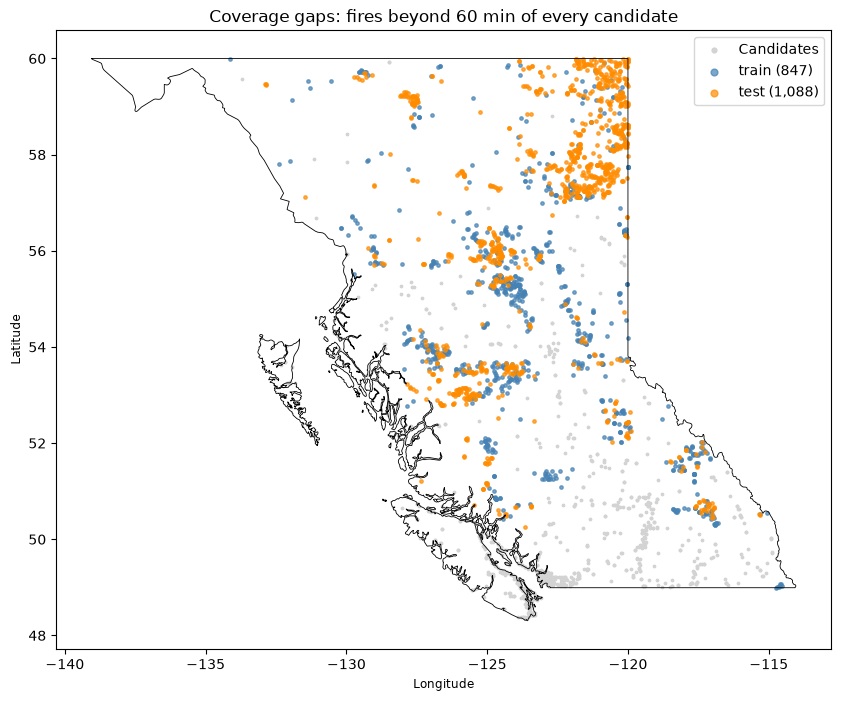

In [9]:
gap_rows, gap_frames = [], []
for split, demand, cost in [("train", demand_train, cost_train), ("test", demand_test, cost_test)]:
    beyond = demand[cost.min(axis=1) > THRESHOLD_MIN].assign(split=split, nearest_minutes=cost.min(axis=1)[cost.min(axis=1) > THRESHOLD_MIN])
    gap_frames.append(beyond)
    totals = demand.groupby("region")["weight"].sum()
    grouped = beyond.groupby("region").agg(fires=("fire_id", "size"), weight=("weight", "sum"))
    grouped["share_of_region_weight"] = grouped["weight"] / totals
    gap_rows.append(grouped.assign(split=split))
    print(f"{split}: {len(beyond):,} of {len(demand):,} fires beyond {THRESHOLD_MIN} min of every candidate "
          f"(weight {beyond['weight'].sum():,.0f}, {beyond['weight'].sum() / demand['weight'].sum():.1%})")
gaps_by_region = pd.concat(gap_rows).reset_index().pivot(index="region", columns="split", values=["fires", "weight", "share_of_region_weight"])
display(gaps_by_region.round(3))
gaps = pd.concat(gap_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 9))
bc.boundary.plot(ax=ax, color="black", linewidth=0.6)
ax.scatter(candidates["lon"], candidates["lat"], s=3, color="lightgrey", label="Candidates")
for split, color in [("train", "steelblue"), ("test", "darkorange")]:
    subset = gaps[gaps["split"] == split]
    ax.scatter(subset["lon"], subset["lat"], s=6, alpha=0.7, color=color, label=f"{split} ({len(subset):,})")
ax.set(title=f"Coverage gaps: fires beyond {THRESHOLD_MIN} min of every candidate", xlabel="Longitude", ylabel="Latitude")
ax.legend(markerscale=2)
plt.show()

save(gaps[["fire_id", "split", "year", "region", "lat", "lon", "weight", "nearest_minutes"]], "gaps_fires.csv")
save(pd.concat(gap_rows).reset_index(), "gaps_by_region.csv")
summary["gaps"] = {split: {"fires": int((gaps["split"] == split).sum()), "weight": float(gaps.loc[gaps["split"] == split, "weight"].sum())}
                   for split in ("train", "test")}

### Leave-one-year-out
Using all five years: for each year, choose 20 stations with capped greedy p-median on the other four years
and score them on the held-out year. Also: how much the chosen sites overlap between folds.

In [10]:
demand_all = pd.concat([demand_train, demand_test], ignore_index=True)
cost_all = np.vstack([cost_train, cost_test])
w_all = demand_all["weight"].to_numpy()
years = demand_all["year"].to_numpy()
loyo_picks, rows = {}, []
for year in sorted(set(years)):
    held_out = years == year
    picks = st.greedy_pmedian(np.minimum(cost_all[~held_out], CAP_MIN), w_all[~held_out], LOYO_K)["picks"]
    inside = st.evaluate(cost_all[~held_out], w_all[~held_out], picks, THRESHOLD_MIN)
    outside = st.evaluate(cost_all[held_out], w_all[held_out], picks, THRESHOLD_MIN)
    loyo_picks[int(year)] = picks
    rows.append({"held_out_year": int(year), "fit_coverage": inside["coverage"], "fit_relative": inside["coverage_relative"],
                 "held_out_coverage": outside["coverage"], "held_out_ceiling": outside["ceiling"],
                 "held_out_relative": outside["coverage_relative"], "held_out_mean_min": outside["mean_minutes"]})
loyo = pd.DataFrame(rows)
display(loyo.set_index("held_out_year").round(3))
pairwise = [jaccard(loyo_picks[a], loyo_picks[b]) for a, b in combinations(loyo_picks, 2)]
LOYO_JACCARD = float(np.mean(pairwise))
frequency = pd.Series([site for picks in loyo_picks.values() for site in picks]).value_counts()
site_frequency = layout(frequency.index).drop(columns="k").assign(folds_selected=frequency.to_numpy())
print(f"Mean pairwise Jaccard between folds: {LOYO_JACCARD:.2f} (min {min(pairwise):.2f}, max {max(pairwise):.2f})")
print(f"{len(frequency)} distinct sites across the 5 folds; selected in all 5: {(frequency == 5).sum()}, "
      f"in 4: {(frequency == 4).sum()}, in only 1: {(frequency == 1).sum()}")
display(site_frequency.head(12))
save(loyo, "loyo_results.csv")
save(site_frequency, "loyo_site_frequency.csv")
summary["loyo"] = {"k": LOYO_K, "mean_pairwise_jaccard": LOYO_JACCARD, "folds": loyo.round(4).to_dict("records"),
                   "sites_in_all_folds": int((frequency == 5).sum()), "distinct_sites": int(len(frequency))}

,fit_coverage,fit_relative,held_out_coverage,held_out_ceiling,held_out_relative,held_out_mean_min
held_out_year,,,,,,
2019,0.291,0.447,0.303,0.810,0.374,97.080
2020,0.287,0.433,0.325,0.841,0.387,83.049
2021,0.285,0.432,0.314,0.751,0.418,89.767
2022,0.295,0.435,0.244,0.704,0.347,128.723
2023,0.377,0.484,0.193,0.511,0.378,152.665


Mean pairwise Jaccard between folds: 0.30 (min 0.18, max 0.48)
49 distinct sites across the 5 folds; selected in all 5: 2, in 4: 7, in only 1: 25


,cand_id,name,kind,region,lat,lon,folds_selected
0,748,Vavenby,town,Kamloops,51.582313,-119.726306,5
1,59,Caycuse Volunteer Fire Department,hall,Coastal,48.888594,-124.367095,5
2,842,Blueberry River,town,Prince George,56.703467,-121.114662,4
3,690,Cherryville,town,Kamloops,50.244640,-118.618601,4
4,769,Anahim Lake,town,Cariboo,52.461867,-125.301819,4
5,698,Sayward,town,Coastal,50.378059,-125.959277,4
6,287,Cranbrook Fire #2,hall,Southeast,49.507835,-115.747541,4
7,815,Middle River,town,Prince George,54.869777,-125.126275,4
8,729,Gold Bridge,town,Kamloops,50.852057,-122.840452,4
9,491,Southbank Firehall,hall,Northwest,54.022750,-125.769854,3


**Region-level stability.** The individual sites change between folds, but does the number of stations each
fire centre gets stay the same? Stations per fire centre for each held-out year, with the standard deviation.

In [11]:
region_stability = pd.DataFrame({f"without_{year}": candidates.loc[picks, "region"].value_counts()
                                 for year, picks in loyo_picks.items()}).fillna(0).astype(int).sort_index()
fold_columns = list(region_stability.columns)
region_stability["mean"] = region_stability[fold_columns].mean(axis=1)
region_stability["std"] = region_stability[fold_columns].std(axis=1, ddof=0)
display(region_stability.round(2))
save(region_stability.reset_index(names="region"), "loyo_region_stability.csv")
summary["loyo"]["region_stability"] = json.loads(region_stability.round(3).reset_index(names="region").to_json(orient="records"))

,without_2019,without_2020,without_2021,without_2022,without_2023,mean,std
region,,,,,,,
Cariboo,2,3,2,3,2,2.4,0.49
Coastal,3,3,3,3,3,3.0,0.00
Kamloops,5,4,3,4,4,4.0,0.63
Northwest,2,2,4,2,3,2.6,0.80
Prince George,4,4,5,5,5,4.6,0.49
Southeast,4,4,3,3,3,3.4,0.49


### Threshold sensitivity
The ceiling at 30, 60 and 90 minutes, and coverage at K = 20 from greedy coverage run at that threshold.

In [12]:
rows = []
for threshold in THRESHOLDS:
    picks = st.greedy_coverage(cost_train, w_train, SENSITIVITY_K, threshold)["picks"]
    train = st.evaluate(cost_train, w_train, picks, threshold)
    test = st.evaluate(cost_test, w_test, picks, threshold)
    rows.append({"threshold_min": threshold, "reach_km": (threshold - config["DISPATCH_MIN"]) / 60 * config["SPEED_KMH"] / config["DETOUR"],
                 "ceiling_train": train["ceiling"], "ceiling_test": test["ceiling"],
                 f"train_coverage_k{SENSITIVITY_K}": train["coverage"], f"test_coverage_k{SENSITIVITY_K}": test["coverage"]})
thresholds_table = pd.DataFrame(rows)
display(thresholds_table.set_index("threshold_min").round(3))
save(thresholds_table, "thresholds.csv")
summary["thresholds"] = thresholds_table.round(4).to_dict("records")

,reach_km,ceiling_train,ceiling_test,train_coverage_k20,test_coverage_k20
threshold_min,,,,,
30,16.667,0.329,0.205,0.104,0.034
60,41.667,0.778,0.511,0.399,0.181
90,66.667,0.932,0.692,0.672,0.391


### Fairness
`greedy_fair` first gives every fire centre one station, then continues as capped greedy p-median.
Compared with plain capped greedy p-median: overall coverage, and the worst-off region's coverage relative
to its own ceiling.

In [13]:
fair_picks = st.greedy_fair(capped_train, w_train, demand_train["region"], candidates["region"], K_MAX)["picks"]
rows, region_rows = [], []
for k in FAIR_KS:
    for method, picks in [("capped p-median", q1["capped"]["picks"]), ("fair", fair_picks)]:
        score = st.evaluate(cost_train, w_train, picks[:k], THRESHOLD_MIN, regions=demand_train["region"])
        worst = score["by_region"]["coverage_relative"]
        rows.append({"k": k, "method": method, "coverage": score["coverage"], "mean_minutes": score["mean_minutes"],
                     "lowest_region": worst.idxmin(), "lowest_region_relative": worst.min(),
                     "regions_with_a_station": candidates.loc[picks[:k], "region"].nunique()})
        region_rows.append(score["by_region"].reset_index().assign(k=k, method=method))
fairness = pd.DataFrame(rows)
fairness_regions = pd.concat(region_rows, ignore_index=True)
display(fairness.set_index(["k", "method"]).round(3))
display(fairness_regions.pivot(index="region", columns=["k", "method"], values="coverage_relative").round(3))
save(fairness, "fairness.csv")
save(fairness_regions, "fairness_by_region.csv")
save(layout(fair_picks), "fairness_picks.csv")
summary["fairness"] = fairness.round(4).to_dict("records")

coverage  mean_minutes lowest_region  \
k  method                                                  
10 capped p-median     0.230       125.000       Cariboo   
   fair                0.222       137.264     Southeast   
20 capped p-median     0.377        92.927     Southeast   
   fair                0.368        93.272     Southeast   
40 capped p-median     0.558        69.663     Southeast   
   fair                0.557        69.848     Southeast   

                    lowest_region_relative  regions_with_a_station  
k  method                                                           
10 capped p-median                   0.000                       5  
   fair                              0.160                       6  
20 capped p-median                   0.338                       6  
   fair                              0.315                       6  
40 capped p-median                   0.612                       6  
   fair                              0.578                       6

k                          10                     20                     40  \
method        capped p-median   fair capped p-median   fair capped p-median   
region                                                                        
Cariboo                 0.000  0.227           0.422  0.434           0.742   
Coastal                 0.296  0.296           0.460  0.387           0.653   
Kamloops                0.340  0.311           0.522  0.523           0.677   
Northwest               0.460  0.460           0.638  0.638           0.813   
Prince George           0.333  0.247           0.481  0.481           0.785   
Southeast               0.182  0.160           0.338  0.315           0.612   

k                     
method          fair  
region                
Cariboo        0.751  
Coastal        0.653  
Kamloops       0.687  
Northwest      0.813  
Prince George  0.785  
Southeast      0.578

### Weight sensitivity
Capped greedy p-median to K = 20 with every fire weighted 1, compared with the weighted version.

In [14]:
unweighted_picks = st.greedy_pmedian(capped_train, np.ones(len(demand_train)), SENSITIVITY_K)["picks"]
weighted_picks = q1["capped"]["picks"][:SENSITIVITY_K]
WEIGHT_JACCARD = jaccard(unweighted_picks, weighted_picks)
weighted_score = st.evaluate(cost_train, w_train, weighted_picks, THRESHOLD_MIN)
unweighted_score = st.evaluate(cost_train, w_train, unweighted_picks, THRESHOLD_MIN)
print(f"Jaccard between weighted and unweighted picks at K={SENSITIVITY_K}: {WEIGHT_JACCARD:.2f} "
      f"({len(set(unweighted_picks) & set(weighted_picks))} of {SENSITIVITY_K} sites in common)")
print(f"Weighted train coverage: weighted picks {weighted_score['coverage']:.1%}, unweighted picks {unweighted_score['coverage']:.1%}")
save(layout(unweighted_picks), "weight_sensitivity_unweighted_picks.csv")
summary["weight_sensitivity"] = {"k": SENSITIVITY_K, "jaccard": WEIGHT_JACCARD,
                                 "sites_in_common": len(set(unweighted_picks) & set(weighted_picks)),
                                 "coverage_weighted_picks": weighted_score["coverage"],
                                 "coverage_unweighted_picks": unweighted_score["coverage"]}

Jaccard between weighted and unweighted picks at K=20: 0.33 (10 of 20 sites in common)
Weighted train coverage: weighted picks 37.7%, unweighted picks 36.7%


### Exact p-median check
The exact p-median has one variable per (demand point, site) pair, so it is run on 20 km demand cells
instead of individual fires. The cells' travel minutes use the same formula and config values as notebook 04;
re-computing one existing 10 km cell first confirms that. Each exact solve has a 120-second limit.

It timed out at K = 5, 10 and 20 (about 957,000 assignment variables), so it is switched off with
`RUN_EXACT_PMEDIAN = False`. The saved "timed out" results are kept and noted in the summary.

In [15]:
if RUN_EXACT_PMEDIAN:
    def travel_minutes(points):
        """Same formula as 04_candidates_costs, from every candidate (columns) to every point (rows)."""
        lat1, lon1 = np.radians(points["lat"].to_numpy())[:, None], np.radians(points["lon"].to_numpy())[:, None]
        lat2, lon2 = np.radians(candidates["lat"].to_numpy())[None, :], np.radians(candidates["lon"].to_numpy())[None, :]
        a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
        km = 2 * config["EARTH_RADIUS_KM"] * np.arcsin(np.sqrt(a))
        return (km * config["DETOUR"] / config["SPEED_KMH"] * 60 + config["DISPATCH_MIN"]).astype(np.float32)


    check_row = len(model["demand_cells"]) // 2
    difference = np.abs(travel_minutes(model["demand_cells"].iloc[[check_row]])[0] - model["cost_cells"][check_row]).max()
    assert difference < 0.01, f"10 km cell {check_row} differs from cost_cells by {difference:.4f} min"
    print(f"Re-computed 10 km cell {check_row}: max difference from cost_cells {difference:.5f} min")

    to_albers = Transformer.from_crs("EPSG:4326", "EPSG:3005", always_xy=True)
    x, y = to_albers.transform(demand_train["lon"].to_numpy(), demand_train["lat"].to_numpy())
    cells = demand_train.assign(cell_x=np.floor(x / (PMEDIAN_CELL_KM * 1000)).astype("int64"),
                                cell_y=np.floor(y / (PMEDIAN_CELL_KM * 1000)).astype("int64"),
                                weighted_lat=demand_train["lat"] * demand_train["weight"],
                                weighted_lon=demand_train["lon"] * demand_train["weight"])
    cells = cells.groupby(["cell_x", "cell_y"]).agg(weight=("weight", "sum"), weighted_lat=("weighted_lat", "sum"),
                                                    weighted_lon=("weighted_lon", "sum")).reset_index()
    cells["lat"], cells["lon"] = cells["weighted_lat"] / cells["weight"], cells["weighted_lon"] / cells["weight"]
    capped_cells = np.minimum(travel_minutes(cells), CAP_MIN)
    w_cells = cells["weight"].to_numpy()
    print(f"{len(cells):,} cells of {PMEDIAN_CELL_KM} km x {len(candidates)} candidates = {capped_cells.size:,} assignment variables")

    rows = []
    for k in EXACT_PMEDIAN_KS:
        started = time.time()
        greedy = st.greedy_pmedian(capped_cells, w_cells, k)
        exact = st.exact_pmedian(capped_cells, w_cells, k, time_limit_s=EXACT_PMEDIAN_LIMIT_S)
        rows.append({"k": k, "greedy_objective": greedy["objective"][-1],
                     "exact_objective": None if exact is None else exact["objective"],
                     "greedy_excess_pct": None if exact is None else 100 * (greedy["objective"][-1] / exact["objective"] - 1),
                     "sites_in_common": None if exact is None else len(set(exact["picks"]) & set(greedy["picks"])),
                     "status": "timed out" if exact is None else "optimal", "seconds": round(time.time() - started)})
        print(rows[-1])
    exact_pmedian_table = pd.DataFrame(rows)
    display(exact_pmedian_table)
    save(exact_pmedian_table, "exact_pmedian_check.csv")
    summary["exact_pmedian"] = {"ran_this_time": True, "saved_results": json.loads(exact_pmedian_table.to_json(orient="records"))}
else:
    saved = RESULTS_DIR / "exact_pmedian_check.csv"
    records = json.loads(pd.read_csv(saved).to_json(orient="records")) if saved.exists() else []
    summary["exact_pmedian"] = {"ran_this_time": False, "saved_results": records,
                                "note": "Skipped (RUN_EXACT_PMEDIAN = False). An earlier run timed out at every K "
                                        f"with a {EXACT_PMEDIAN_LIMIT_S} s limit; those results are kept."}
    print(summary["exact_pmedian"]["note"])
    display(pd.DataFrame(records))

Skipped (RUN_EXACT_PMEDIAN = False). An earlier run timed out at every K with a 120 s limit; those results are kept.


,k,greedy_objective,exact_objective,greedy_excess_pct,sites_in_common,status,seconds
0,5,1.908457e+06,None,None,None,timed out,197
1,10,1.700934e+06,None,None,None,timed out,186
2,20,1.410034e+06,None,None,None,timed out,199


## Save the summary

In [16]:
_ = (RESULTS_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=float), encoding="utf-8")
for path in sorted(RESULTS_DIR.iterdir()):
    print(f"{path.stat().st_size / 1000:8.1f} kB  {path.name}")

     1.4 kB  baselines.csv
     0.3 kB  exact_coverage_check.csv
     0.2 kB  exact_pmedian_check.csv
     0.6 kB  fairness.csv
     3.2 kB  fairness_by_region.csv
     3.9 kB  fairness_picks.csv
     0.6 kB  gaps_by_region.csv
   142.5 kB  gaps_fires.csv
     0.3 kB  loyo_region_stability.csv
     0.7 kB  loyo_results.csv
     3.2 kB  loyo_site_frequency.csv
     7.4 kB  q1_curve_capped.csv
     7.4 kB  q1_curve_uncapped.csv
     3.9 kB  q1_picks_capped.csv
     3.9 kB  q1_picks_uncapped.csv
    23.4 kB  q2_curve.csv
     6.0 kB  q2_stations_trucks.csv
     1.3 kB  q2_summary.json
     0.3 kB  q3_comparison.csv
     0.7 kB  q3_evaluation.json
    41.5 kB  q3_hall_trucks_allocations.csv
     1.0 kB  q3_halls_by_region.csv
     3.5 kB  q3_matching_layout.csv
     2.4 kB  q3_next_stations.csv
    14.8 kB  summary.json
     0.4 kB  thresholds.csv
     1.3 kB  weight_sensitivity_unweighted_picks.csv
